In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import json
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
warnings.filterwarnings('ignore')

In [2]:
with open('all_breeds.pkl', 'rb') as f:
    all_breeds = pickle.load(f)

In [3]:
BASE_PATH = '../dog-breed-identification/dog-breed-identification/'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
LABELS_PATH = os.path.join(BASE_PATH, 'labels.csv')

In [4]:
labels_df = pd.read_csv(LABELS_PATH)
breeds_to_idx = {breed:  idx for idx, breed in enumerate(sorted(all_breeds))}
idx_to_bread = {idx: breed for breed, idx in breeds_to_idx.items()}
labels_df['label'] = labels_df['breed'].map(breeds_to_idx)

In [5]:
print(f"\nDataset Info:")
print(f"  Total images: {len(labels_df)}")
print(f"  Total breeds: {len(all_breeds)}")
print(f"  Label range: 0-{len(all_breeds)-1}")


Dataset Info:
  Total images: 10222
  Total breeds: 120
  Label range: 0-119


In [6]:
for breed, idx in sorted(breeds_to_idx.items(), key=lambda x: x[1])[:10]:
    count = len(labels_df[labels_df['breed'] == breed])
    print(f"  {idx:3d}. {breed:30s} - {count:4d} images")

    0. affenpinscher                  -   80 images
    1. afghan_hound                   -  116 images
    2. african_hunting_dog            -   86 images
    3. airedale                       -  107 images
    4. american_staffordshire_terrier -   74 images
    5. appenzeller                    -   78 images
    6. australian_terrier             -  102 images
    7. basenji                        -  110 images
    8. basset                         -   82 images
    9. beagle                         -  105 images


In [7]:
train_df, temp_df = train_test_split(
    labels_df,
    test_size=0.3,
    stratify=labels_df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"\nSplit Summary:")
print(f"  Train: {len(train_df):5d} images ({len(train_df)/len(labels_df)*100:.1f}%)")
print(f"  Val:   {len(val_df):5d} images ({len(val_df)/len(labels_df)*100:.1f}%)")
print(f"  Test:  {len(test_df):5d} images ({len(test_df)/len(labels_df)*100:.1f}%)")
print(f"  Total: {len(labels_df):5d} images")



Split Summary:
  Train:  7155 images (70.0%)
  Val:    1533 images (15.0%)
  Test:   1534 images (15.0%)
  Total: 10222 images


In [8]:
print(f"{'Breed':<30} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>6}")
sample_breeds = sorted(all_breeds)[:10]
for breed in sample_breeds:
    train_count = len(train_df[train_df['breed'] == breed])
    val_count = len(val_df[val_df['breed'] == breed])
    test_count = len(test_df[test_df['breed'] == breed])
    total_count = train_count + val_count + test_count
    print(f"{breed:<30} {train_count:6d} {val_count:6d} {test_count:6d} {total_count:6d}")

Breed                           Train    Val   Test  Total
affenpinscher                      56     12     12     80
afghan_hound                       81     17     18    116
african_hunting_dog                60     13     13     86
airedale                           75     16     16    107
american_staffordshire_terrier     52     11     11     74
appenzeller                        55     12     11     78
australian_terrier                 71     15     16    102
basenji                            77     16     17    110
basset                             57     13     12     82
beagle                             74     15     16    105


In [9]:
train_df[['id', 'breed', 'label']].to_csv('train_split.csv', index=False)
val_df[['id', 'breed', 'label']].to_csv('val_split.csv', index=False)
test_df[['id', 'breed', 'label']].to_csv('test_split.csv', index=False)
print("Saved: train_split.csv, val_split.csv, test_split.csv")

Saved: train_split.csv, val_split.csv, test_split.csv


In [11]:
img_size = 224

def calculate_mean_std(df, img_path, target_size=224, sample_size=500):
    from tqdm import tqdm

    sample_ids = np.random.choice(df['id'].values, min(sample_size, len(df)), replace=False)
    pixel_values = []

    for img_id in tqdm(sample_ids, desc="Processing images"):
        try:
            img_file = os.path.join(img_path, f"{img_id}.jpg")
            img = load_img(img_file, target_size=(target_size, target_size))
            img_array = img_to_array(img)/255.0
            pixel_values.append(img_array)
        except Exception as e:
            continue
    
    pixel_values = np.array(pixel_values)
         
    mean = pixel_values.mean(axis=(0, 1, 2))
    std = pixel_values.std(axis=(0, 1, 2))

    return mean, std

mean, std = calculate_mean_std(train_df, TRAIN_PATH, target_size=img_size, sample_size=500)

print(f"\nDataset Statistics (RGB):")
print(f"  Mean: [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]")
print(f"  Std:  [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]")

# Calculate class weights for imbalanced classes (IMPORTANT for 120 classes!)
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)
class_weights = total_samples / (len(class_counts) * class_counts.values)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"\nClass Weights Statistics:")
print(f"  Min weight: {class_weights.min():.4f}")
print(f"  Max weight: {class_weights.max():.4f}")
print(f"  Mean weight: {class_weights.mean():.4f}")
print(f"  ⚠ Using class weights is CRITICAL for handling imbalance!")

# Save statistics
dataset_stats = {
    'mean': mean.tolist(),
    'std': std.tolist(),
    'class_weights': class_weights.tolist(),
    'class_weight_dict': class_weight_dict,
    'breed_to_idx': breeds_to_idx,
    'idx_to_breed': idx_to_bread,
    'num_classes': len(all_breeds),
    'img_size': img_size
}

with open('dataset_stats.json', 'w') as f:
    json.dump(dataset_stats, f, indent=2)

print("\n✓ Saved: dataset_stats.json")

Processing images: 100%|██████████| 500/500 [00:10<00:00, 45.98it/s]



Dataset Statistics (RGB):
  Mean: [0.4694, 0.4465, 0.3816]
  Std:  [0.2589, 0.2550, 0.2618]

Class Weights Statistics:
  Min weight: 0.6776
  Max weight: 1.2962
  Mean weight: 1.0223
  ⚠ Using class weights is CRITICAL for handling imbalance!

✓ Saved: dataset_stats.json


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=lambda x: (x - mean) / std
)

# Validation/Test data generator (NO augmentation, only normalization)
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: (x - mean) / std
)

print("✓ Training augmentation pipeline:")
print("  - Rescale to [0, 1]")
print("  - Random rotation (±15 degrees)")
print("  - Random width/height shift (10%)")
print("  - Random shear (10%)")
print("  - Random zoom (10%)")
print("  - Random horizontal flip")
print("  - Normalize with calculated mean/std")

print("\n✓ Validation/Test pipeline:")
print("  - Rescale to [0, 1]")
print("  - Normalize with calculated mean/std")

✓ Training augmentation pipeline:
  - Rescale to [0, 1]
  - Random rotation (±15 degrees)
  - Random width/height shift (10%)
  - Random shear (10%)
  - Random zoom (10%)
  - Random horizontal flip
  - Normalize with calculated mean/std

✓ Validation/Test pipeline:
  - Rescale to [0, 1]
  - Normalize with calculated mean/std


In [13]:
train_df['filepath'] = train_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))
val_df['filepath'] = val_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))
test_df['filepath'] = test_df['id'].apply(lambda x: os.path.join(TRAIN_PATH, f"{x}.jpg"))

# Convert labels to strings for flow_from_dataframe
train_df['label_str'] = train_df['breed'].astype(str)
val_df['label_str'] = val_df['breed'].astype(str)
test_df['label_str'] = test_df['breed'].astype(str)

batch_size = 32

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"✓ Batch size: {batch_size}")
print(f"✓ Train generator: {len(train_generator)} batches")
print(f"✓ Val generator: {len(val_generator)} batches")
print(f"✓ Test generator: {len(test_generator)} batches")


Found 7155 validated image filenames belonging to 120 classes.
Found 1533 validated image filenames belonging to 120 classes.
Found 1534 validated image filenames belonging to 120 classes.
✓ Batch size: 32
✓ Train generator: 224 batches
✓ Val generator: 48 batches
✓ Test generator: 48 batches


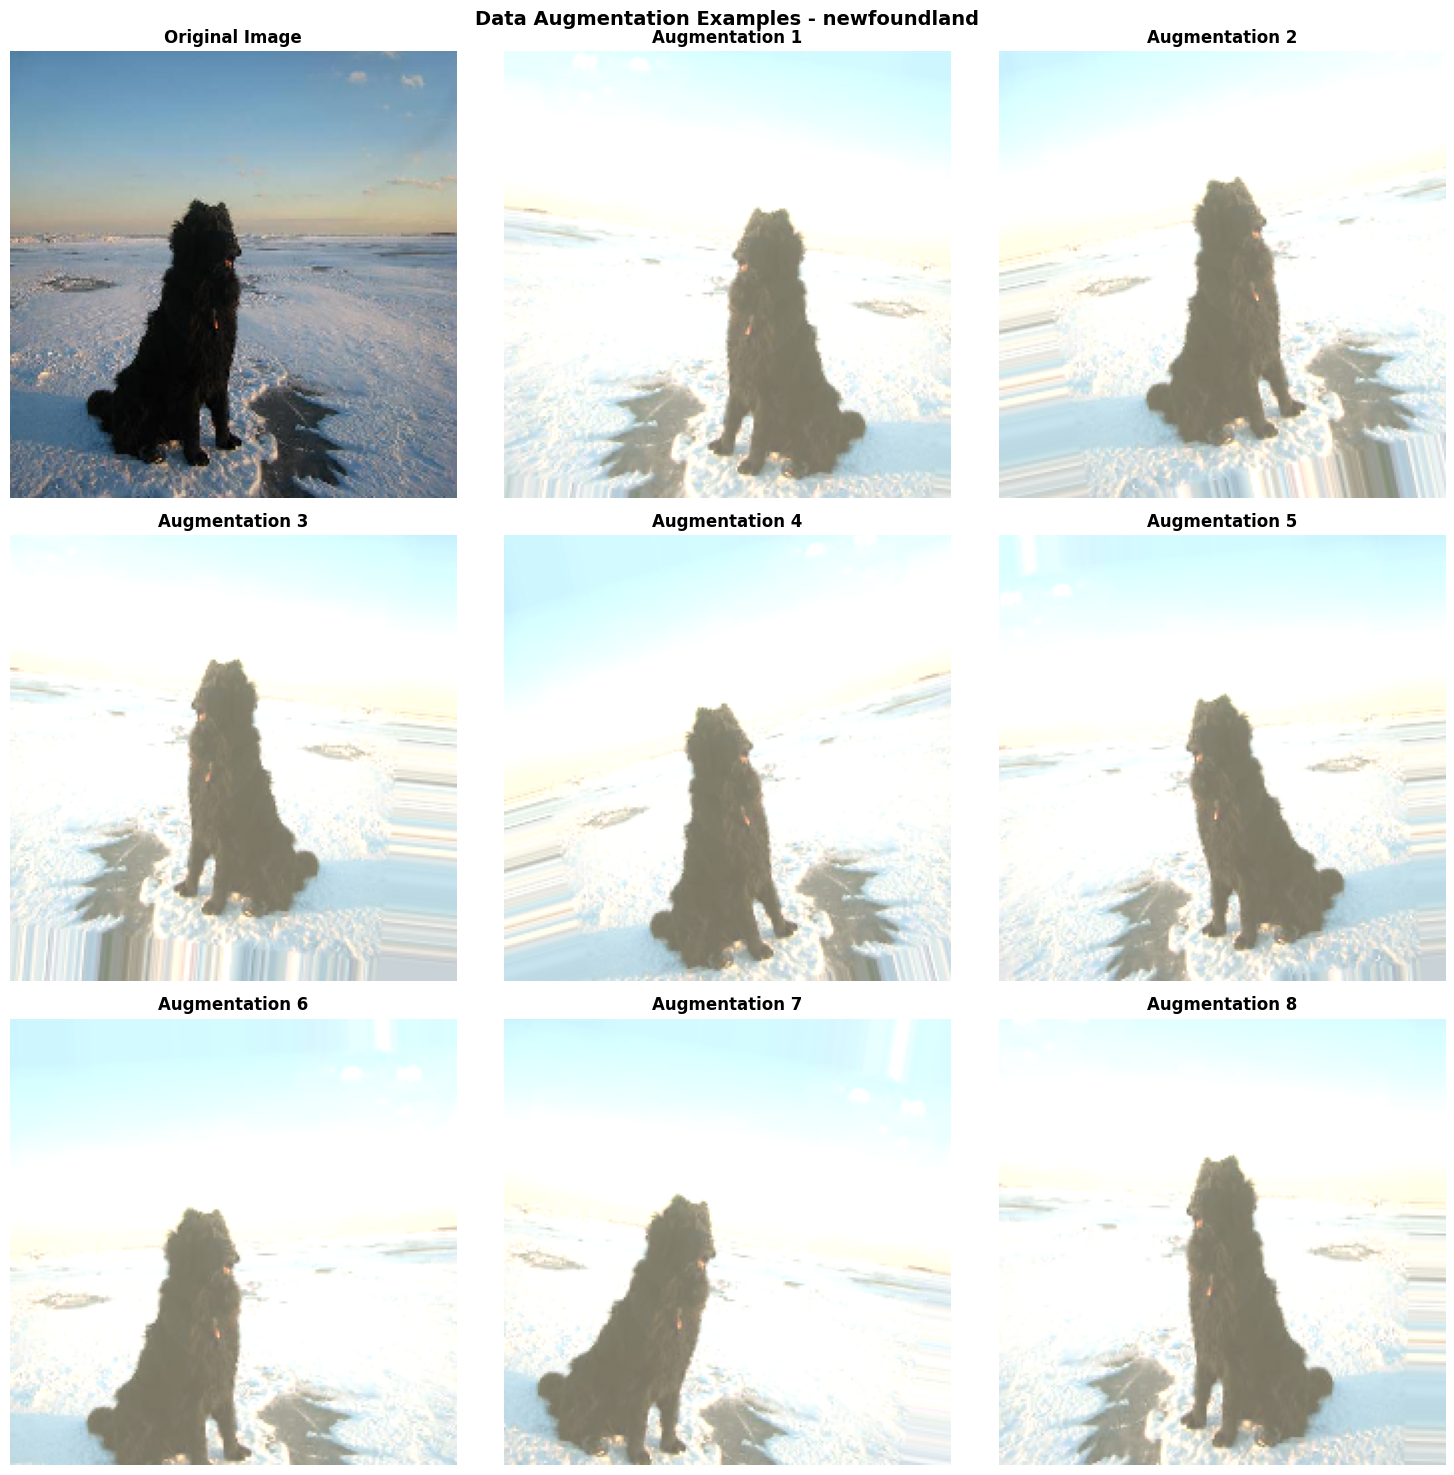

✓ Saved: augmentation_examples.png


In [14]:
sample_idx = 0
sample_id = train_df.iloc[sample_idx]['id']
sample_breed = train_df.iloc[sample_idx]['breed']
sample_img_path = os.path.join(TRAIN_PATH, f"{sample_id}.jpg")
sample_img = load_img(sample_img_path, target_size=(img_size, img_size))
sample_img_array = img_to_array(sample_img)

# Create augmented versions
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

# Original image
axes[0].imshow(sample_img)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Apply augmentation 8 times
sample_img_batch = np.expand_dims(sample_img_array, 0)
aug_iter = train_datagen.flow(sample_img_batch, batch_size=1)

for i in range(1, 9):
    aug_img = next(aug_iter)[0]
    # Denormalize for visualization
    aug_img = (aug_img * std + mean)
    aug_img = np.clip(aug_img, 0, 1)
    
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentation {i}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f'Data Augmentation Examples - {sample_breed}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: augmentation_examples.png")

Batch shape: (32, 224, 224, 3)
Labels shape: (32, 120)


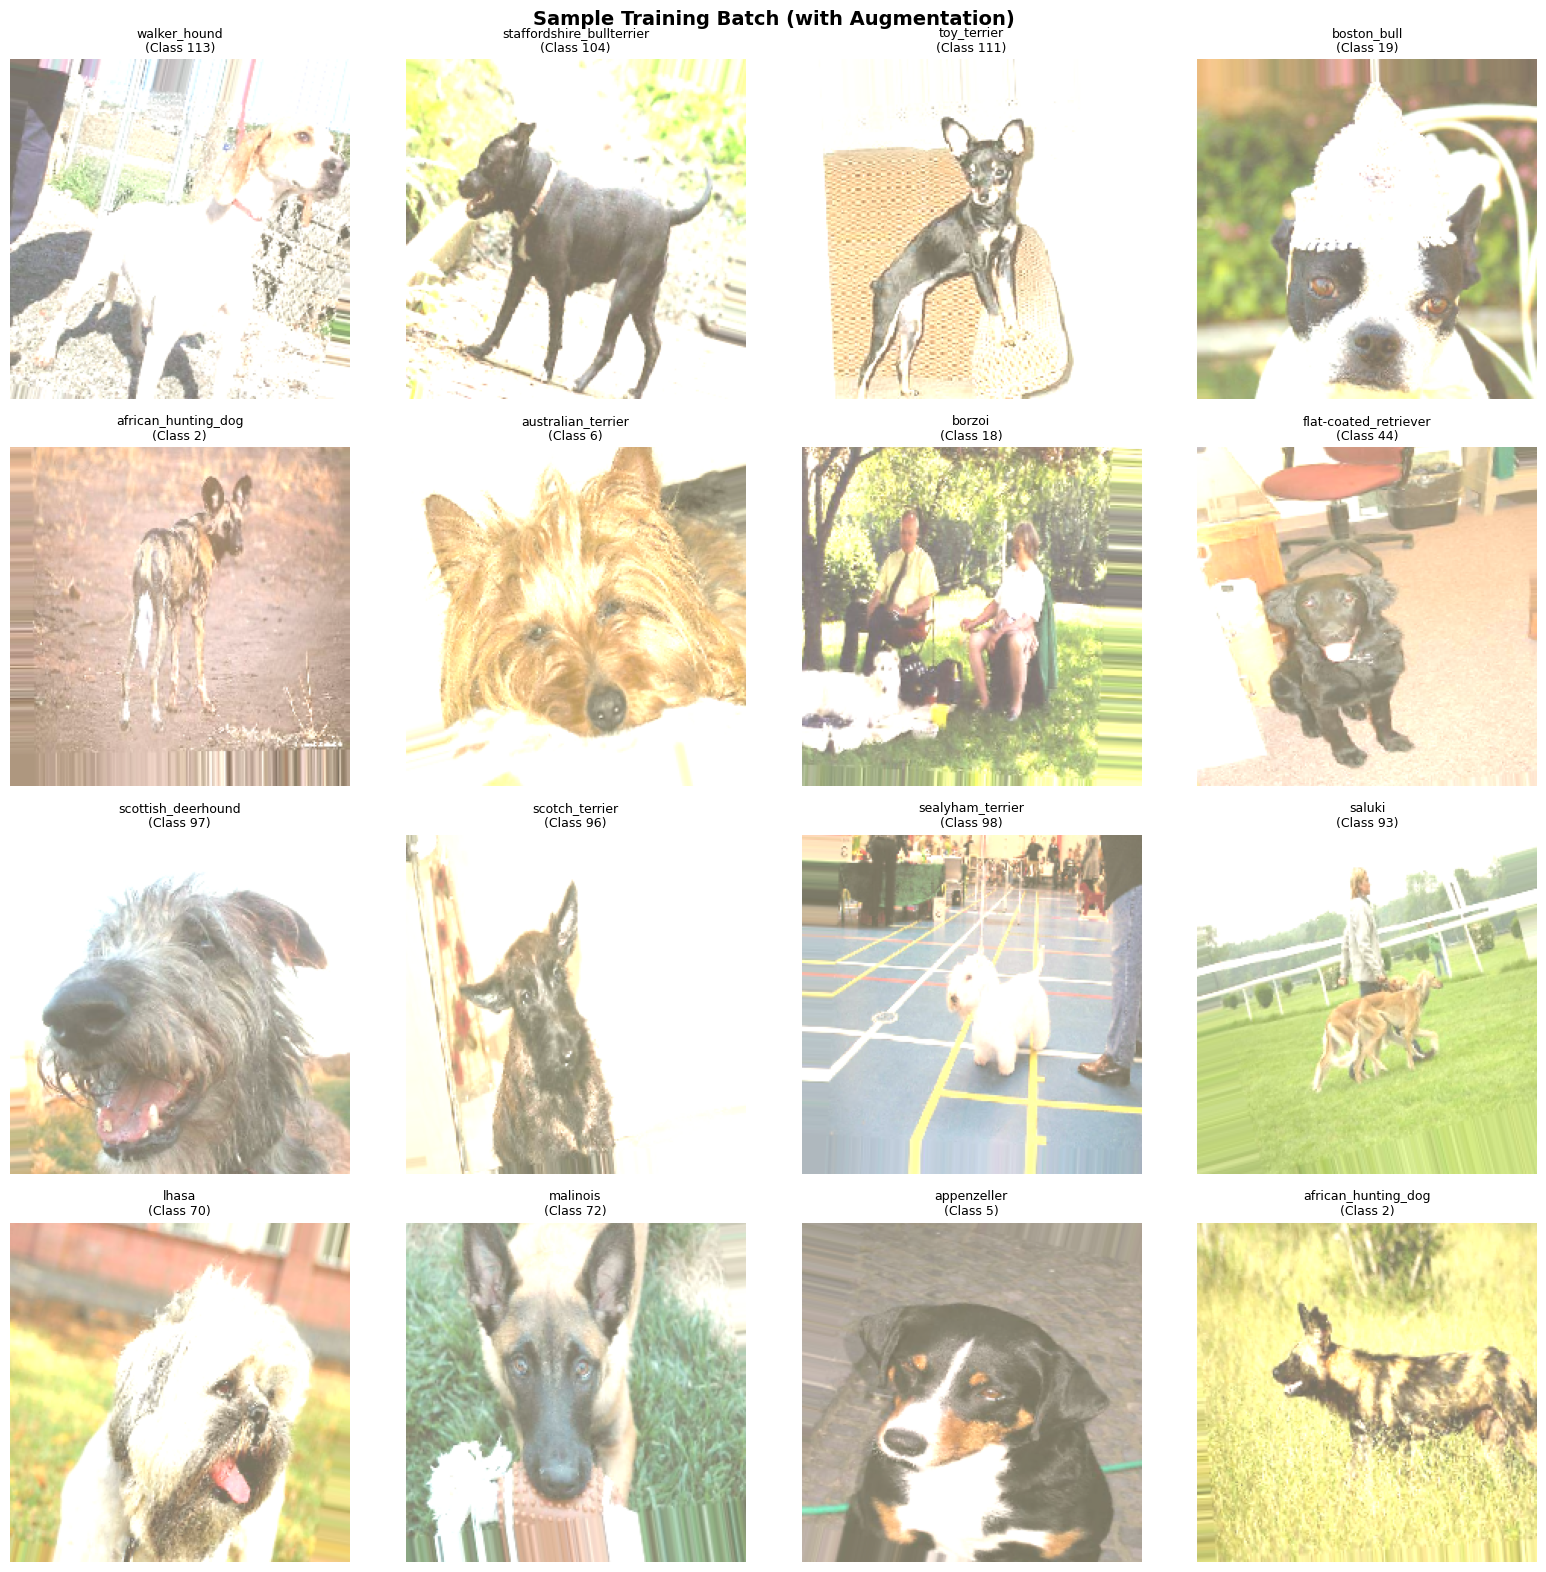

✓ Saved: sample_training_batch.png


In [16]:
images_batch, labels_batch = next(train_generator)

print(f"Batch shape: {images_batch.shape}")
print(f"Labels shape: {labels_batch.shape}")

# Display 16 images from batch
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i in range(min(16, len(images_batch))):
    # Denormalize image
    img = (images_batch[i] * std + mean)
    img = np.clip(img, 0, 1)
    
    # Get label
    label_idx = np.argmax(labels_batch[i])
    breed_name = idx_to_bread[label_idx]
    
    axes[i].imshow(img)
    axes[i].set_title(f'{breed_name}\n(Class {label_idx})', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Training Batch (with Augmentation)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_training_batch.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sample_training_batch.png")

In [18]:
print("PREPROCESSING COMPLETED SUCCESSFULLY!")
print("=" * 70)

print("\nGenerated Files:")
print("  ✓ train_split.csv, val_split.csv, test_split.csv")
print("  ✓ dataset_stats.json")
print("  ✓ augmentation_examples.png")
print("  ✓ sample_training_batch.png")

print("\nDataset Ready for Training:")
print(f"  Classes: {len(all_breeds)} dog breeds")
print(f"  Train: {len(train_df)} images")
print(f"  Val: {len(val_df)} images")
print(f"  Test: {len(test_df)} images")
print(f"  Image size: {img_size}x{img_size}")

PREPROCESSING COMPLETED SUCCESSFULLY!

Generated Files:
  ✓ train_split.csv, val_split.csv, test_split.csv
  ✓ dataset_stats.json
  ✓ augmentation_examples.png
  ✓ sample_training_batch.png

Dataset Ready for Training:
  Classes: 120 dog breeds
  Train: 7155 images
  Val: 1533 images
  Test: 1534 images
  Image size: 224x224
